# 05b — Random Forest Model Training

---
### Workflow in this notebook:
1. Load shared `X_train.csv`, `y_train.csv`, `X_test.csv`, `y_test.csv`.
2. Build preprocessing pipeline (`OneHotEncoder` for categories + passthrough for numericals).
3. 5-Fold Stratified Cross-Validation on the training set.
4. Fit Random Forest on full `X_train`.
5. Quick evaluation on `X_test` + Feature Importance inspection.
6. Save the trained pipeline to `../ml/saved_models/random_forest_pipeline.pkl`.

In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

## 1. Load Shared Split Data

In [2]:
# Load the shared training and test CSV files
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Load label encoder
label_encoder = joblib.load('../ml/saved_models/label_encoder.pkl')

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"Target classes: {label_encoder.classes_} -> {label_encoder.transform(label_encoder.classes_)}")

X_train shape: (4000, 13)
X_test shape:  (1000, 13)
Target classes: ['High' 'Low' 'Medium'] -> [0 1 2]


## 2. Define Features & Preprocessing Pipeline

In [3]:
categorical_features = ['Platform', 'Content_Type', 'Category', 'Day_of_Week', 'Sentiment', 'Influencer_Tier']
numerical_features = ['Hour_of_Day', 'Month', 'Hashtag_Count', 'Content_Length', 'Follower_Count', 'Has_Media', 'Is_Verified']

# For Tree models, numerical scaling is not required; passthrough is used
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ]
)

# Build complete Pipeline: Preprocessing + Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
])

print("Pipeline constructed successfully:")
print(rf_pipeline)

Pipeline constructed successfully:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Platform', 'Content_Type',
                                                   'Category', 'Day_of_Week',
                                                   'Sentiment',
                                                   'Influencer_Tier']),
                                                 ('num', 'passthrough',
                                                  ['Hour_of_Day', 'Month',
                                                   'Hashtag_Count',
                                                   'Content_Length',
                                                   'Follower_Count',
                                                   'Has_Media',
                                                   'Is_Verified'])])),
    

## 3. 5-Fold Stratified Cross-Validation on Training Data

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_pipeline, X_train, y_train, cv=cv, scoring='f1_macro')

print(f"5-Fold CV Macro F1 Scores: {[round(s, 4) for s in cv_scores]}")
print(f"Mean CV Macro F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

5-Fold CV Macro F1 Scores: [np.float64(0.7019), np.float64(0.7126), np.float64(0.6984), np.float64(0.7166), np.float64(0.7041)]
Mean CV Macro F1: 0.7067 (+/- 0.0068)


## 4. Fit Model on Full Training Set

In [5]:
# Train on all 2,420 training posts
rf_pipeline.fit(X_train, y_train)
print("Random Forest pipeline fitted successfully!")

Random Forest pipeline fitted successfully!


## 5. Preliminary Evaluation on Test Set

In [6]:
y_pred = rf_pipeline.predict(X_test)

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')

print(f"Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print(f"Test Macro F1: {macro_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Test Accuracy: 0.7430 (74.30%)
Test Macro F1: 0.7421

Classification Report:
              precision    recall  f1-score   support

        High       0.83      0.89      0.86       332
         Low       0.76      0.69      0.73       334
      Medium       0.63      0.65      0.64       334

    accuracy                           0.74      1000
   macro avg       0.74      0.74      0.74      1000
weighted avg       0.74      0.74      0.74      1000



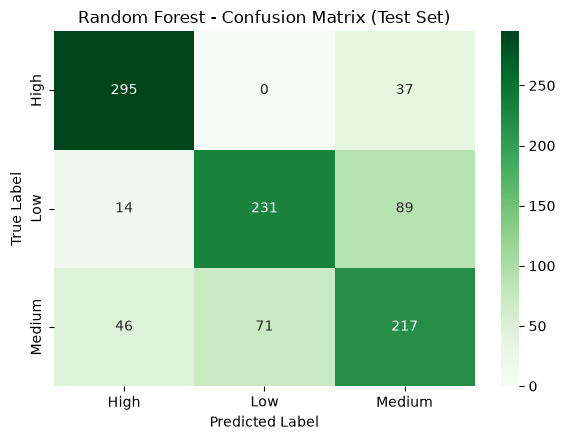

In [7]:
# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Random Forest - Confusion Matrix (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## 6. Save Model to Shared Folder for Team Evaluation

In [10]:
joblib.dump(rf_pipeline, '../ml/saved_models/random_forest_pipeline.pkl')

['../ml/saved_models/random_forest_pipeline.pkl']